# Parte 1.-Modelo pigeonhole

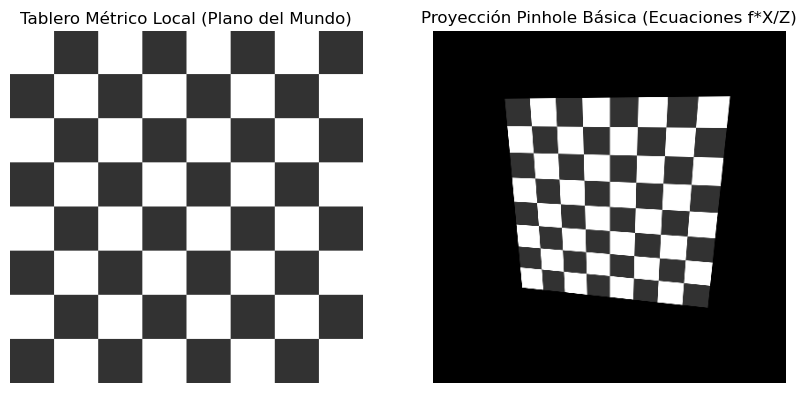

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERAR EL PATRÓN MÉTRICO EN EL MUNDO (2D Local)
# ==========================================
# Forzamos enteros de Python para evitar incompatibilidades con SageMath
size_grid = int(400)
grid_size = int(50)
chessboard = np.zeros((size_grid, size_grid, 3), dtype=np.uint8)

for i in range(size_grid):
    for j in range(size_grid):
        if (i // grid_size + j // grid_size) % 2 == 0:
            chessboard[i, j] = [255, 255, 255]  # Blanco (valores RGB explícitos)
        else:
            chessboard[i, j] = [50, 50, 50]      # Gris oscuro

# ==========================================
# 2. PARÁMETROS DEL MODELO PINHOLE BÁSICO
# ==========================================
# Solo definimos la focal f (en píxeles) y el centro físico del lienzo
f = float(350.0)
cx = float(size_grid / 2.0)
cy = float(size_grid / 2.0)

# ==========================================
# 3. DEFINIR EL PLANO EN EL ESPACIO 3D (ax + by + cz = d)
# ==========================================
# Un plano inclinado en el espacio que no pasa por el origen (d != 0)
a, b, c = 0.2, -0.3, 1.0
d = 6.0  

normal = np.array([a, b, c], dtype=np.float64)
normal_norm = normal / np.linalg.norm(normal)

# Construimos una base ortonormal (u, v) sobre el plano para colocar nuestro tablero
if abs(normal_norm[0]) < 0.9:
    u = np.cross(normal_norm, np.array([1.0, 0.0, 0.0], dtype=np.float64))
else:
    u = np.cross(normal_norm, np.array([0.0, 1.0, 0.0], dtype=np.float64))
u /= np.linalg.norm(u)
v = np.cross(normal_norm, u)
v /= np.linalg.norm(v)

# Punto de origen (centro del tablero) sobre el plano 3D (Z = d/c si X=0, Y=0)
X0 = np.array([0.0, 0.0, d/c], dtype=np.float64)

# ==========================================
# 4. PROYECTAR EL TABLERO 3D USANDO EL MODELO PINHOLE BÁSICO
# ==========================================
# El tablero mide físicamente 4.0 x 4.0 metros en el espacio tridimensional
half_w = float(2.0)
half_h = float(2.0)
local_corners = np.array([
    [-half_w, -half_h],  # Superior Izquierda
    [half_w, -half_h],   # Superior Derecha
    [half_w, half_h],    # Inferior Derecha
    [-half_w, half_h]    # Inferior Izquierda
], dtype=np.float64)

pts_distorted = []
for pt in local_corners:
    # 1. Calculamos la posición 3D (X, Y, Z) de la esquina en el espacio real
    P_3d = X0 + pt[0] * u + pt[1] * v
    X, Y, Z = P_3d[0], P_3d[1], P_3d[2]
    
    # 2. Aplicamos las ecuaciones del modelo pinhole básico (perspectiva)
    x_proj = f * (X / Z)
    y_proj = f * (Y / Z)
    
    # 3. Trasladamos al sistema de coordenadas de la imagen (origen en esquina superior izq)
    u_pixel = x_proj + cx
    v_pixel = y_proj + cy
    
    pts_distorted.append([u_pixel, v_pixel])

pts_distorted = np.array(pts_distorted, dtype=np.float32)

# ==========================================
# 5. GENERAR LA IMAGEN DE ENTRADA CON PERSPECTIVA
# ==========================================
pts_ideal = np.array([
    [0.0, 0.0],
    [size_grid - 1, 0.0],
    [size_grid - 1, size_grid - 1],
    [0.0, size_grid - 1]
], dtype=np.float32)

H_distort = cv2.getPerspectiveTransform(pts_ideal, pts_distorted)
imagen_clase = cv2.warpPerspective(chessboard, H_distort, (int(size_grid), int(size_grid)))

# Mostrar los resultados
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Tablero Métrico Local (Plano del Mundo)")
plt.imshow(chessboard)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Proyección Pinhole Básica (Ecuaciones f*X/Z)")
plt.imshow(imagen_clase)
plt.axis('off')
plt.show()

In [12]:
# ==========================================
# VISUALIZACIÓN GEOMÉTRICA 3D (Sagemath)
# ==========================================
var('x y z')

# 1. Definimos el plano inclinado del espacio 3D (ax + by + cz = d)
a, b, c = 0.2, -0.3, 1.0
d = 6.0
P_plano = implicit_plot3d(a*x + b*y + c*z == d, (x, -4, 4), (y, -4, 4), (z, 1, 8), 
                          color='lightblue', opacity=0.3, title="Escena 3D")

# 2. El Centro Óptico (Cámara) situado en el origen (0,0,0)
C_centro = point3d((0, 0, 0), size=15, color='red', label="Centro Óptico (0,0,0)")

# Reconstruimos las esquinas 3D del tablero físicamente en el espacio (del cálculo de Celda 1)
import numpy as np
normal = np.array([a, b, c], dtype=float)
normal_norm = normal / np.linalg.norm(normal)
if abs(normal_norm[0]) < 0.9:
    u = np.cross(normal_norm, np.array([1.0, 0.0, 0.0]))
else:
    u = np.cross(normal_norm, np.array([0.0, 1.0, 0.0]))
u /= np.linalg.norm(u)
v = np.cross(normal_norm, u)
v /= np.linalg.norm(v)
X0 = np.array([0.0, 0.0, d/c])

half_w, half_h = 2.0, 2.0
local_corners = [[-half_w, -half_h], [half_w, -half_h], [half_w, half_h], [-half_w, half_h]]
pts_3d = [X0 + pt[0]*u + pt[1]*v for pt in local_corners]

# 3. Dibujamos el tablero de ajedrez físico en el espacio 3D (Polígono verde)
T_tablero = polygon3d(pts_3d, color='green', opacity=0.5, label="Tablero en Plano del Mundo")

# 4. Plano de la Imagen Virtual (Pinhole) colocado a la distancia focal f
# Para que se aprecie visualmente en el gráfico a mitad de camino, lo situamos en z = 2.0
z_focal = 2.0
P_sensor = implicit_plot3d(z == z_focal, (x, -2, 2), (y, -2, 2), (z, z_focal-0.05, z_focal+0.05), 
                            color='pink', opacity=0.4)

# 5. Calculamos y dibujamos los puntos proyectados en el sensor (Z = z_focal)
pts_sensor_3d = []
for P in pts_3d:
    escala = z_focal / P[2] # Pinhole: f * (X/Z)
    pts_sensor_3d.append([P[0]*escala, P[1]*escala, z_focal])

T_proyectado = polygon3d(pts_sensor_3d, color='red', opacity=0.8)
Puntos_sensor = point3d(pts_sensor_3d, size=8, color='black')

# 6. Rayos de Proyección (Líneas que van desde la cámara a los puntos 3D pasando por el sensor)
Rayos = Graphics()
for P in pts_3d:
    Rayos += line3d([(0,0,0), P], color='orange', thickness=1.5)

# Combinamos todos los elementos en un único gráfico interactivo
escena_3d = C_centro + P_plano + T_tablero + P_sensor + T_proyectado + Puntos_sensor + Rayos
escena_3d.show(aspect_ratio=1, frame=True, axes=True)

Graphics3d Object

In [13]:
# ==========================================
# VISUALIZACIÓN GEOMÉTRICA 3D CON TEXTURA DE AJEDREZ (Sagemath)
# ==========================================
var('x y z')

# 1. Definimos el plano inclinado del espacio 3D (ax + by + cz = d)
a, b, c = 0.2, -0.3, 1.0
d = 6.0
P_plano = implicit_plot3d(a*x + b*y + c*z == d, (x, -4, 4), (y, -4, 4), (z, 1, 8), 
                          color='lightblue', opacity=0.15, title="Simulación Física Pinhole 3D")

# 2. El Centro Óptico (Cámara) en el origen (0,0,0)
C_centro = point3d((0, 0, 0), size=20, color='red', label="Centro Óptico (0,0,0)")

# 3. Base ortonormal sobre el plano inclinado para orientar el tablero
import numpy as np
normal = np.array([a, b, c], dtype=float)
normal_norm = normal / np.linalg.norm(normal)
if abs(normal_norm[2]) < 0.9:
    u = np.cross(normal_norm, np.array([1.0, 0.0, 0.0]))
else:
    u = np.cross(normal_norm, np.array([0.0, 1.0, 0.0]))
u /= np.linalg.norm(u)
v = np.cross(normal_norm, u)
v /= np.linalg.norm(v)
X0 = np.array([0.0, 0.0, d/c]) # Centro del tablero

# 4. Plano de la Imagen Virtual (Sensor de la Cámara a z = z_focal)
z_focal = 2.0
P_sensor = implicit_plot3d(z == z_focal, (x, -2, 2), (y, -2, 2), (z, z_focal-0.02, z_focal+0.02), 
                            color='pink', opacity=0.3)

# ==========================================
# GENERACIÓN DE LAS 64 CASILLAS EN EL MUNDO Y EN EL SENSOR
# ==========================================
T_tablero = Graphics()
T_proyectado = Graphics()

num_casillas = 8
casilla_size = 4.0 / num_casillas  # El tablero mide 4.0x4.0 metros en el mundo

for i in range(num_casillas):
    for j in range(num_casillas):
        # Coordenadas locales de los límites de cada casilla (de -2.0 a 2.0)
        u_min = -2.0 + i * casilla_size
        u_max = -2.0 + (i + 1) * casilla_size
        v_min = -2.0 + j * casilla_size
        v_max = -2.0 + (j + 1) * casilla_size
        
        # 4 vértices locales de la casilla
        casilla_local = [
            [u_min, v_min],
            [u_max, v_min],
            [u_max, v_max],
            [u_min, v_max]
        ]
        
        # Coordenadas 3D de la casilla en el mundo físico
        pts_casilla_3d = [X0 + pt[0]*u + pt[1]*v for pt in casilla_local]
        
        # Coordenadas 3D proyectadas en el sensor (Z = z_focal) usando pinhole f*X/Z
        pts_casilla_sensor = []
        for P in pts_casilla_3d:
            escala = z_focal / P[2]
            pts_casilla_sensor.append([P[0]*escala, P[1]*escala, z_focal])
            
        # Color alterno de ajedrez
        color_casilla = '#f0f0f0' if (i + j) % 2 == 0 else '#222222'
        
        # Añadir casilla al tablero físico en 3D
        T_tablero += polygon3d(pts_casilla_3d, color=color_casilla, opacity=0.85)
        
        # Añadir casilla proyectada en el plano del sensor
        T_proyectado += polygon3d(pts_casilla_sensor, color=color_casilla, opacity=0.95)

# 5. Rayos principales de luz (conectamos las 4 esquinas exteriores)
Rayos = Graphics()
esquinas_exteriores = [
    X0 - 2*u - 2*v,
    X0 + 2*u - 2*v,
    X0 + 2*u + 2*v,
    X0 - 2*u + 2*v
]
for P in esquinas_exteriores:
    Rayos += line3d([(0,0,0), P], color='orange', thickness=2)

# Unir todo el escenario
escenario_completo = C_centro + P_plano + T_tablero + P_sensor + T_proyectado + Rayos
escenario_completo.show(aspect_ratio=1, frame=True, axes=True)

Graphics3d Object

# Parte 2: coordenadas homogéneas
## Funciones
- homog(x) e inhomog(x) pone o quita un 1 al final del vector
- fig(w,h) y readrgb(file) dibuja o lee una imagen
- shcont(c, color='blue', nodes=True) muestra un polígono cuyos nodos son las filas de un array 2D
- shpoint(p, color='blue'): muestra un punto cartesiano
- shline(l,xmin=-2000,xmax=2000, color='red'): dibuja una recta "infinita"
- cross(u,v): devuelve el producto vectorial ya normalizado


In [14]:
import numpy as np
import numpy.linalg as la
import cv2   as cv
import matplotlib.pyplot as plt

def homog(x):
    ax = np.array(x)
    uc = np.ones(ax.shape[:-1]+(1,))
    return np.append(ax,uc,axis=-1)


# convierte en coordenadas tradicionales
def inhomog(x):
    ax = np.array(x)
    return ax[..., :-1] / ax[...,[-1]] 
    
def fig(w,h):
    plt.figure(figsize=(w,h))

def readrgb(file):
    return cv.cvtColor( cv.imread(file), cv.COLOR_BGR2RGB) 

# muestra un polígono cuyos nodos son las filas de un array 2D
def shcont(c, color='blue', nodes=True):
    x = c[:,0]
    y = c[:,1]
    x = np.append(x,x[0])
    y = np.append(y,y[0])
    plt.plot(x,y,color)
    if nodes: plt.plot(x,y,'.',color=color, markersize=11)

# muestra un punto cartesiano
def shpoint(p, color='blue'):
    plt.plot(p[0],p[1],'.',color=color, markersize=15)        

# dibuja una recta "infinita"
def shline(l,xmin=-2000,xmax=2000, color='red'):
    a,b,c = l / la.norm(l)
    if abs(b) < 1e-6:
        x = -c/a
        r = np.array([[x,-2000],[x,2000]])
    else:
        y0 = (-a*xmin - c) / b
        y1 = (-a*xmax - c) / b
        r = np.array([[xmin,y0],[xmax,y1]])
    shcont(r,color=color,nodes=False)

def cross(u,v):
    r = np.cross(u,v)
    return r / la.norm(r)

p=[1. 2. 1.]
q=[4. 4. 1.]
l=[-2.  3. -4.]


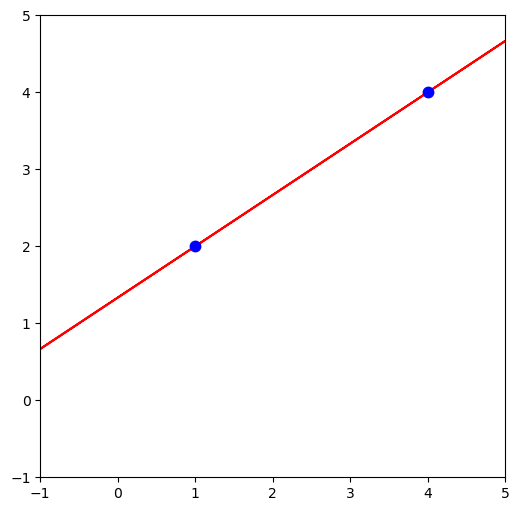

In [15]:
# Recta que pasa por dos puntos
p, q = homog([(1,2),
              (4,4)])
print(f'p={p}')
print(f'q={q}')

l = np.cross(p,q)

print(f'l={l}')

fig(6,6); plt.axis([-1,5,-1,5]);
shline(l)
shpoint(p)
shpoint(q)

p=[ 9 10  3]


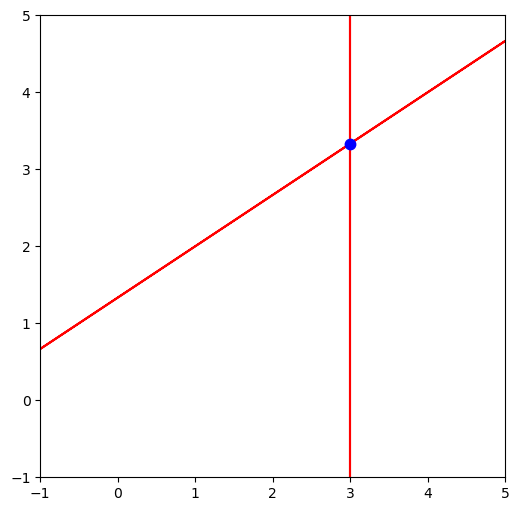

In [16]:
# Intersección de dos rectas
l = (2,-3,4)
m = (1,0,-3)

p = np.cross(l,m)

print(f'p={p}')

fig(6,6); plt.axis([-1,5,-1,5]);
shline(l)
shline(m)
shpoint(inhomog(p))

[15 10  0]


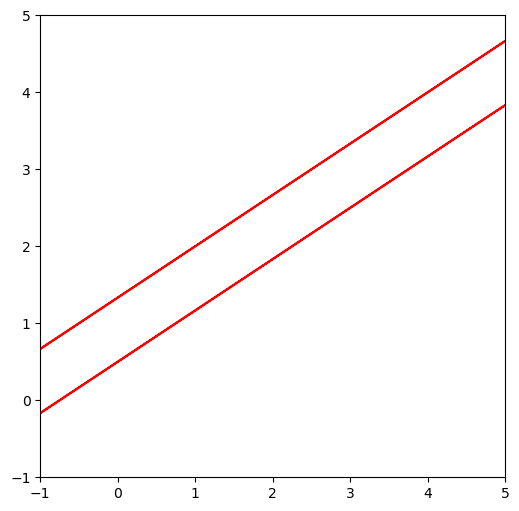

In [17]:
# Punto del infinito resultante de la intersección de dos rectas
l = (2,-3,4)
m = (4,-6,3)

p = np.cross(l,m)
print(p)

fig(6,6); plt.axis([-1,5,-1,5]);
shline(l)
shline(m)

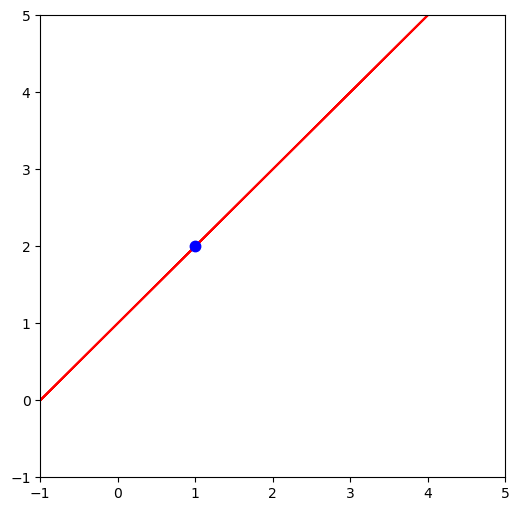

In [18]:
#  recta que pasa por un punto (1,2) y el punto del infinito en la dirección diagonal (1,1,0) 
fig(6,6); plt.axis([-1,5,-1,5]);

shline(cross((1,2,1),(1,1,0)))
shpoint((1,2))

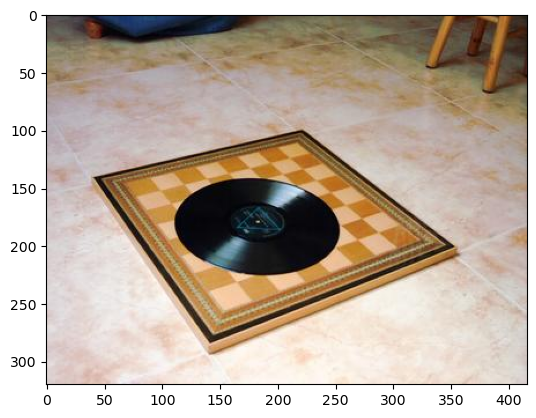

In [19]:
# Leer imagen
img = readrgb('disk1.jpg')

plt.imshow(img);

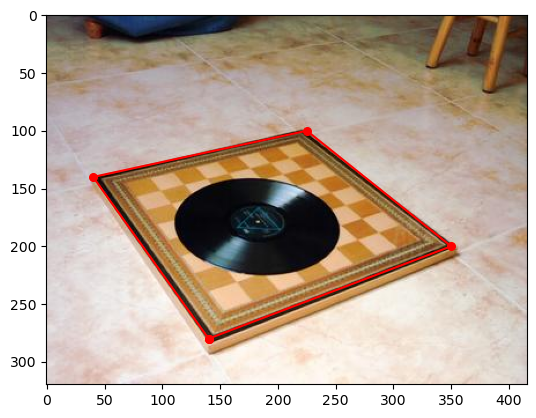

In [20]:
# Esquinas (coordenadas tomadas a ojo)
ref = np.array([
        [140,280],
        [40,140],
        [225,100],
        [350,200]])

plt.imshow(img);
shcont(ref,color='red')

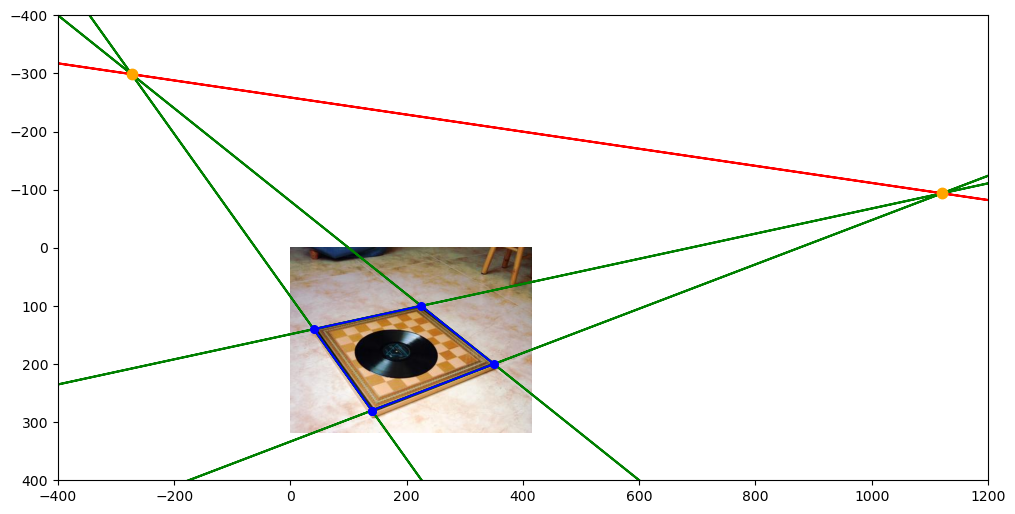

In [21]:
# Puntos y recta del infinito a partir de esas esquinas
r0,r1,r2,r3 = href = homog(ref)
l1 = cross(r1,r2)
l2 = cross(r0,r3)

l3 = cross(r0,r1)
l4 = cross(r2,r3)

ph = cross(l1,l2)
qh = cross(l3,l4)

p = inhomog(ph)
q = inhomog(qh)

horiz = cross(ph,qh)

fig(12,12)
plt.imshow(img)

shline(l1,color='green')
shline(l2,color='green')
shline(l3,color='green')
shline(l4,color='green')
shline(horiz,color='red')
shcont(ref);
shpoint(p,color='orange')
shpoint(q,color='orange')

plt.axis([-400,1200,400,-400]);


In [22]:
# En una vista frontal de un rectángulo los puntos de fuga están en el infinito y el horizonte no se puede dibujar, pero la ecuación de la recta se calcula bien
ref = np.array([
        [0,0],
        [0,1],
        [2,1],
        [2,0]])

href = homog(ref)

l1 = cross(href[1,:],href[2,:])
l2 = cross(href[0,:],href[3,:])

l3 = cross(href[0,:],href[1,:])
l4 = cross(href[2,:],href[3,:])

ph = cross(l1,l2)
qh = cross(l3,l4)

horiz = cross(ph,qh)

print(horiz)

[ 0.  0. -1.]


# Parte 3.- Homografías

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Rectangle

def create_grid(density=11):
    """Crea una rejilla de coordenadas en el rango [-1, 1] x [-1, 1]."""
    x = np.linspace(-1, 1, density)
    y = np.linspace(-1, 1, density)
    lines = []
    for yi in y:
        lines.append(np.array([[xi, yi, 1.0] for xi in np.linspace(-1, 1, 50)]))
    for xi in x:
        lines.append(np.array([[xi, yi, 1.0] for yi in np.linspace(-1, 1, 50)]))
    return lines

grid_lines = create_grid(density=9)

unit_square = np.array([
    [-1, -1, 1],
    [ 1, -1, 1],
    [ 1,  1, 1],
    [-1,  1, 1],
    [-1, -1, 1]
])

def apply_homography(H, points):
    """Aplica H y normaliza por la coordenada homogénea w'."""
    pts_trans = (H @ points.T).T
    w = pts_trans[:, 2:3]
    valid = np.abs(w) > 1e-4
    pts_trans[~valid.flatten()] = np.nan
    return pts_trans[:, :2] / w

def draw_colored_matrix(ax, H):
    """Dibuja la matriz H con codificación de color por bloques semánticos."""
    ax.clear()
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.axis('off')
    ax.set_title("Estructura Matricial de $H$", fontsize=12, fontweight='bold', pad=15)

    # Colores pastel para cada bloque
    color_linear = '#D0E1FD'      # Azul suave: Transformación lineal 2x2
    color_trans = '#D1F2D9'       # Verde suave: Traslación
    color_proj = '#FDE2D2'        # Salmón/Naranja suave: Perspectiva
    color_scale = '#EDEDED'       # Gris suave: Escala global

    cell_colors = [
        [color_linear, color_linear, color_trans],
        [color_linear, color_linear, color_trans],
        [color_proj,   color_proj,   color_scale]
    ]

    for i in range(3):
        for j in range(3):
            val = H[i, j]
            # Coordenadas invertidas en Y para formato estándar de matriz
            y_pos = 2 - i
            x_pos = j
            
            # Dibujar celda
            rect = Rectangle((x_pos + 0.05, y_pos + 0.05), 0.9, 0.9,
                             facecolor=cell_colors[i][j], edgecolor='#555555', lw=1.2)
            ax.add_patch(rect)
            
            # Valor numérico dentro de la celda
            ax.text(x_pos + 0.5, y_pos + 0.5, f"{val:+.2f}",
                    ha='center', va='center', fontsize=12, fontweight='bold', color='#222222')

    # Leyenda explicativa inferior
    legend_items = [
        (color_linear, "Lineal (A): rotación / escala / cizalla"),
        (color_trans,  "Afín (t): traslación"),
        (color_proj,   "Proyectivo (vᵀ): fuga / perspectiva")
    ]
    for idx, (col, text) in enumerate(legend_items):
        y_leg = -0.3 - idx * 0.35
        rect = Rectangle((0.05, y_leg), 0.25, 0.22, facecolor=col, edgecolor='#555555', lw=1)
        ax.add_patch(rect)
        ax.text(0.35, y_leg + 0.11, text, ha='left', va='center', fontsize=9.5)
        
    ax.set_ylim(-1.3, 3)

def plot_homography(h11, h12, h13,
                    h21, h22, h23,
                    h31, h32):
    
    H = np.array([
        [h11, h12, h13],
        [h21, h22, h23],
        [h31, h32, 1.0]
    ])
    
    # 3 paneles: Plano original, Plano transformado y Matriz coloreada
    fig = plt.figure(figsize=(16, 5.5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.1, 0.9])
    
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])
    
    # --- 1. Espacio Original ---
    ax0.set_title("Espacio Original (2D)", fontsize=12, fontweight='bold')
    for line in grid_lines:
        ax0.plot(line[:, 0], line[:, 1], color='#DDDDDD', lw=1)
    ax0.plot(unit_square[:, 0], unit_square[:, 1], 'b-', lw=2.2, label='Cuadrado unitario')
    ax0.scatter([0], [0], color='black', zorder=5)
    ax0.set_xlim(-2.5, 2.5)
    ax0.set_ylim(-2.5, 2.5)
    ax0.set_aspect('equal')
    ax0.grid(True, linestyle=':', alpha=0.6)
    ax0.axhline(0, color='black', lw=0.6)
    ax0.axvline(0, color='black', lw=0.6)

    # Recta de fuga w=0 en el espacio original
    if abs(h31) > 1e-4 or abs(h32) > 1e-4:
        x_vals = np.array([-2.5, 2.5])
        if abs(h32) > 1e-4:
            y_vals = -(h31 * x_vals + 1.0) / h32
            ax0.plot(x_vals, y_vals, 'm--', lw=1.6, label='Recta de fuga ($w=0$)')
        else:
            x_val = -1.0 / h31
            ax0.axvline(x_val, color='m', linestyle='--', lw=1.6, label='Recta de fuga ($w=0$)')
    ax0.legend(loc='upper right', fontsize=8.5)

    # --- 2. Espacio Transformado ---
    ax1.set_title(r"Espacio Transformado: $\mathbf{x}' \sim H \mathbf{x}$", fontsize=12, fontweight='bold')
    for line in grid_lines:
        trans_line = apply_homography(H, line)
        ax1.plot(trans_line[:, 0], trans_line[:, 1], color='#B4D4F7', lw=1)
        
    trans_square = apply_homography(H, unit_square)
    ax1.plot(trans_square[:, 0], trans_square[:, 1], 'r-', lw=2.2, label='Polígono transformado')
    
    # Origen transformado
    origin_trans = apply_homography(H, np.array([[0.0, 0.0, 1.0]]))
    if not np.isnan(origin_trans).any():
        ax1.scatter(origin_trans[:, 0], origin_trans[:, 1], color='red', zorder=5)
        ax1.text(origin_trans[0, 0] + 0.08, origin_trans[0, 1] + 0.08,
                 f"t = ({h13:.2f}, {h23:.2f})", fontsize=9, color='darkred', fontweight='bold')

    ax1.set_xlim(-3, 3)
    ax1.set_ylim(-3, 3)
    ax1.set_aspect('equal')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.axhline(0, color='black', lw=0.6)
    ax1.axvline(0, color='black', lw=0.6)
    ax1.legend(loc='upper right', fontsize=8.5)

    # --- 3. Matriz Coloreada ---
    draw_colored_matrix(ax2, H)
    
    plt.tight_layout()
    plt.show()

# --- Interfaz de Controles (Sliders) ---
style = {'description_width': '65px'}
layout = widgets.Layout(width='260px')

# Fila 1: Lineal X (azul) y Traslación X (verde)
s_h11 = widgets.FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.1, description='h11 (sx):', style=style, layout=layout)
s_h12 = widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='h12 (shx):', style=style, layout=layout)
s_h13 = widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='h13 (tx):', style=style, layout=layout)

# Fila 2: Lineal Y (azul) y Traslación Y (verde)
s_h21 = widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='h21 (shy):', style=style, layout=layout)
s_h22 = widgets.FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.1, description='h22 (sy):', style=style, layout=layout)
s_h23 = widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='h23 (ty):', style=style, layout=layout)

# Fila 3: Términos Proyectivos (naranja)
s_h31 = widgets.FloatSlider(value=0.0, min=-0.8, max=0.8, step=0.05, description='h31 (px):', style=style, layout=layout)
s_h32 = widgets.FloatSlider(value=0.0, min=-0.8, max=0.8, step=0.05, description='h32 (py):', style=style, layout=layout)

ui = widgets.VBox([
    widgets.HTML("<h3 style='margin-bottom: 10px;'>Explorador de la Matriz de Homografía</h3>"),
    widgets.HBox([s_h11, s_h12, s_h13]),
    widgets.HBox([s_h21, s_h22, s_h23]),
    widgets.HBox([s_h31, s_h32, widgets.Label(value="h33 = 1.0 (Escala fijada)", layout=layout)])
])

out = widgets.interactive_output(plot_homography, {
    'h11': s_h11, 'h12': s_h12, 'h13': s_h13,
    'h21': s_h21, 'h22': s_h22, 'h23': s_h23,
    'h31': s_h31, 'h32': s_h32
})

display(ui, out)

Output()

# Parte 3.- Estimación: DLT

In [24]:
#Celda 2: Estimación manual de la Homografía (Solo con NumPy)
#Aquí los alumnos programan el sistema de ecuaciones lineales Ah=b que vieron en la teoría para calcular la matriz H de 3×3 (asumiendo h 33
def calcular_homografia_manual(src, dst):
    """
    Calcula la homografía H que mapea los puntos src a dst.
    Se asume que h33 = 1 para resolver el sistema de 8 ecuaciones con 8 incógnitas.
    """
    A = []
    b = []
    for i in range(4):
        x, y = src[i]
        xp, yp = dst[i]
        
        # Ecuación para la coordenada x' de destino
        # h11*x + h12*y + h13 - h31*x*x' - h32*y*x' = x'
        A.append([x, y, 1, 0, 0, 0, -x*xp, -y*xp])
        b.append(xp)
        
        # Ecuación para la coordenada y' de destino
        # h21*x + h22*y + h23 - h31*x*y' - h32*y*y' = y'
        A.append([0, 0, 0, x, y, 1, -x*yp, -y*yp])
        b.append(yp)
        
    # Resolver el sistema lineal Ah = b
    A = np.array(A, dtype=np.float64)
    b = np.array(b, dtype=np.float64)
    
    h = np.linalg.solve(A, b)
    
    # Añadimos el término h33 = 1 y damos forma de matriz 3x3
    H = np.append(h, 1.0).reshape(3, 3)
    return H

# Para rectificar, queremos mapear los puntos distorsionados de la "foto" 
# de vuelta a las esquinas perfectas de un cuadrado de salida (ej. 300x300 px)
pts_src = pts_distorted # Esquinas medidas en la foto
pts_dst = np.array([
    [0, 0],
    [300, 0],
    [300, 300],
    [0, 300]
], dtype=np.float32)

H_manual = calcular_homografia_manual(pts_src, pts_dst)
print("Matriz de Homografía Rectificadora (Calculada a mano):\n")
print(H_manual)

Matriz de Homografía Rectificadora (Calculada a mano):

[[ 1.11856416e-02  1.14814525e+00 -8.99743052e+01]
 [-1.15724993e+00 -1.21621654e-01  3.97666200e+02]
 [ 5.40540034e-04 -8.10810772e-04  1.00000000e+00]]


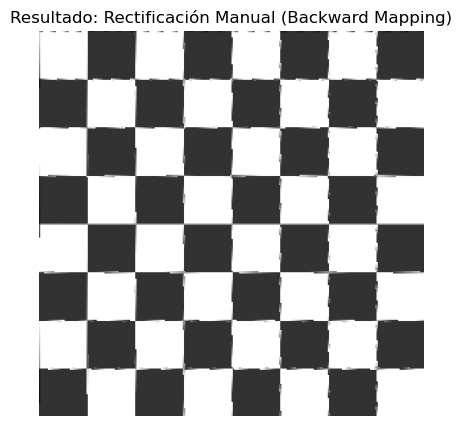

In [25]:

#Celda 3: Deformación por Mapeo Inverso (Backward Mapping)
#Los alumnos comprueban de forma práctica por qué es obligatorio proyectar hacia atrás para evitar que queden píxeles vacíos (huecos negros) en la imagen rectificada.
def warp_perspectiva_manual(img_src, H, size_dst):
    """
    Aplica la homografía H sobre img_src usando Backward Mapping.
    size_dst es una tupla (ancho, alto) para la imagen de salida.
    """
    w_dst, h_dst = size_dst
    img_dst = np.zeros((h_dst, w_dst, 3), dtype=np.uint8)
    
    # Calculamos la inversa de H para viajar desde el destino al origen
    H_inv = np.linalg.inv(H)
    
    h_src, w_src, _ = img_src.shape
    
    # Iteramos sobre cada píxel de la imagen de salida (destino)
    for yd in range(h_dst):
        for xd in range(w_dst):
            # 1. Punto destino en coordenadas homogéneas
            pt_dst = np.array([xd, yd, 1.0])
            
            # 2. Proyectamos hacia atrás para buscar el píxel correspondiente en el origen
            pt_src = H_inv @ pt_dst
            
            # 3. Rompemos la homogeneidad (división por la tercera coordenada 'w')
            xs_homo = pt_src[0] / pt_src[2]
            ys_homo = pt_src[1] / pt_src[2]
            
            # 4. Redondeo al vecino más cercano
            xs = int(round(xs_homo))
            ys = int(round(ys_homo))
            
            # 5. Si cae dentro de la imagen original, copiamos el color
            if 0 <= xs < w_src and 0 <= ys < h_src:
                img_dst[yd, xd] = img_src[ys, xs]
                
    return img_dst

# Ejecutamos nuestra función manual
rectificada_manual = warp_perspectiva_manual(imagen_clase, H_manual, (300, 300))

plt.figure(figsize=(5, 5))
plt.title("Resultado: Rectificación Manual (Backward Mapping)")
plt.imshow(rectificada_manual)
plt.axis('off')
plt.show()


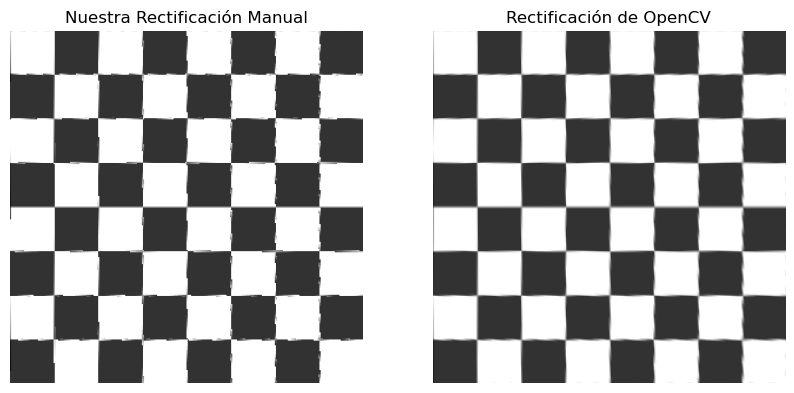

Matriz Manual (Normalizada):
 [[ 1.11856416e-02  1.14814525e+00 -8.99743052e+01]
 [-1.15724993e+00 -1.21621654e-01  3.97666200e+02]
 [ 5.40540034e-04 -8.10810772e-04  1.00000000e+00]]

Matriz OpenCV (Normalizada):
 [[ 1.11856416e-02  1.14814525e+00 -8.99743052e+01]
 [-1.15724993e+00 -1.21621654e-01  3.97666200e+02]
 [ 5.40540034e-04 -8.10810772e-04  1.00000000e+00]]


In [26]:
# 1. OpenCV calcula H con algoritmos robustos
H_opencv = cv2.getPerspectiveTransform(pts_src, pts_dst)

# 2. Convertimos explícitamente a tipo int nativo de Python fuera de la función
ancho_destino = int(300)
alto_destino = int(300)

# 3. cv2.warpPerspective ahora recibirá los tipos nativos correctos
rectificada_opencv = cv2.warpPerspective(imagen_clase, H_opencv, (ancho_destino, alto_destino))

# Comparación visual de resultados
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Nuestra Rectificación Manual")
plt.imshow(rectificada_manual)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Rectificación de OpenCV")
plt.imshow(rectificada_opencv)
plt.axis('off')
plt.show()

# Verificación de que las matrices calculadas son numéricamente equivalentes
# Escalamos la esquina inferior derecha a 1 para poder comparar las matrices
H_manual_normalizada = H_manual / H_manual[2, 2]
H_opencv_normalizada = H_opencv / H_opencv[2, 2]

print("Matriz Manual (Normalizada):\n", H_manual_normalizada)
print("\nMatriz OpenCV (Normalizada):\n", H_opencv_normalizada)
